# Linear Regression From Scratch

Ahhh yes the most classical of machine learning techniques. 

$$ y = mx + b$$

Every machine learning algorithm needs a loss function, and for this the simplest is just Mean Square Error:

$$MSE = \sum_{i}(y_{i} - \hat{y_{i}})^2$$

Subbing in $$y_i = mx_i + b$$

We get $$MSE = \sum_{i}(y_{i} - mx_i + b)^2$$

Taking the partial derivative with respect to m:

$$\frac{\partial MSE}{\partial m} = \frac{1}{n} * \sum_{i}-2x_i (y_{i} - mx_i + b)\\=\frac{-2}{n} * \sum_{i}x_i (y_{i} - mx_i + b)$$

Now with respect to b:
$$\frac{\partial MSE}{\partial m} = \frac{1}{n} * \sum_{i}-2 * (y_{i} - mx_i + b)\\=\frac{-2}{n} * \sum_{i}(y_{i} - mx_i + b)$$

Okie dokes. So the optimization will be done by the following:
$$m = m - L * \frac{\partial MSE}{\partial m}\\[1em]b = b - L * \frac{\partial MSE}{\partial b}$$

Where L is the learning rate. This is basically gradient descent (Wauw)

And ye thats pretty much it. Isn't that cool. 

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [4]:
# 1. Set a random seed for reproducibility
np.random.seed(42)

# 2. Define the size of the dataset
num_samples = 200

# 3. Define the TRUE parameters of our linear relationship
# Equation: y = (w1 * x1) + (w2 * x2) + b + noise
TRUE_W1 = 3.5
TRUE_W2 = -2.0
TRUE_B = 12.5

# 4. Generate independent features (X)
# Feature 1: e.g., Hours Studied (ranging from 1 to 10)
hours_studied = np.random.uniform(1, 10, size=num_samples)

# Feature 2: e.g., Sleep Hours (ranging from 4 to 9)
sleep_hours = np.random.uniform(4, 9, size=num_samples)

# 5. Generate random Gaussian noise (to simulate real-world variance)
# Mean = 0, Standard Deviation = 1.5
noise = np.random.normal(0, 1.5, size=num_samples)

# 6. Calculate the dependent target variable (y) using our true formula
exam_score = (TRUE_W1 * hours_studied) + (TRUE_W2 * sleep_hours) + TRUE_B + noise

# 7. Combine everything into a Pandas DataFrame
df = pd.DataFrame({
    'Hours_Studied': hours_studied,
    'Sleep_Hours': sleep_hours,
    'Exam_Score': exam_score
})

# 8. Save to CSV (optional, so you can easily load it into your model script)
# df.to_csv("linear_regression_data.csv", index=False)

# Display the first few rows
print("--- First 5 rows of the generated dataset ---")
print(df.head())


--- First 5 rows of the generated dataset ---
   Hours_Studied  Sleep_Hours  Exam_Score
0       4.370861     7.210158   15.335915
1       9.556429     4.420700   37.137607
2       7.587945     4.808144   30.464451
3       6.387926     8.492771   17.406800
4       2.404168     7.032145    7.336546


In [7]:
def MSE(m, b, points):
    total_error = 0
    for i in range(len(points)):
        x = points.iloc[i]["Hours_Studied"]
        y = points.iloc[i]["Exam_Score"]
        total_error += (y - (m * x + b))**2
    total_error /= float(len(points))
    return total_error

def gradient_descent(m_now, b_now, points, learning_rate):
    m_gradient = 0
    b_gradient = 0

    n = len(points)
    # Use partial derivatives here
    for i in range(n):
        x = points.iloc[i]["Hours_Studied"]
        y = points.iloc[i]["Exam_Score"]

        m_gradient += -2/n * x * (y - (m_now * x + b_now)) 
        b_gradient += -2/n * (y - (m_now * x + b_now)) 

    m = m_now - m_gradient * learning_rate
    b = b_now - b_gradient * learning_rate
    return m, b




In [24]:
m = 0
b = 0
learning_rate = 0.001
epochs = 1000

for i in range(epochs):
    m, b = gradient_descent(m, b, df, learning_rate)

print(m, b)



3.406052523150333 0.11362090421911429


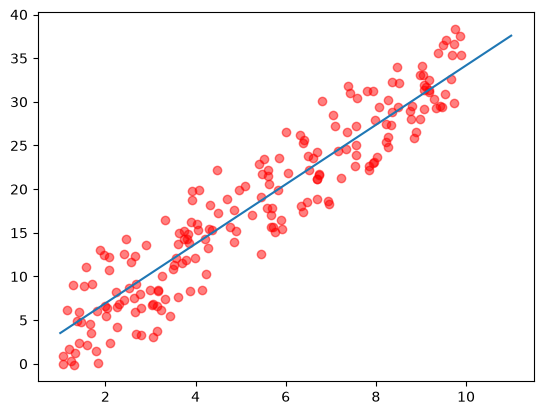

In [13]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"], alpha = 0.5, color = "red")
plt.plot(list(range(1, 12)), [m * x + b for x in range(1, 12)])
plt.show()


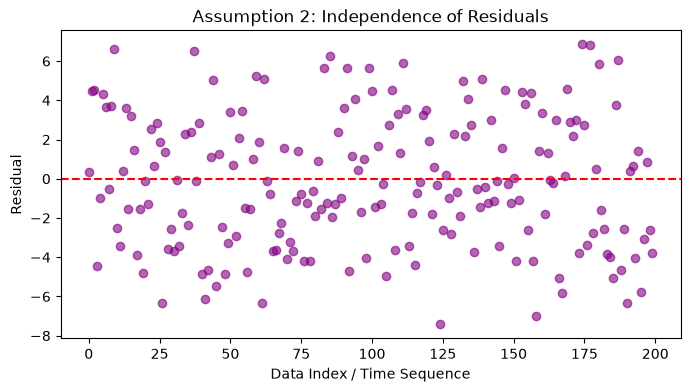

In [30]:
# Calculate predictions and residuals
df['y_pred'] = m * df["Hours_Studied"] + b
df['residuals'] = df["Exam_Score"] - df['y_pred']

# Plot residuals sequentially
plt.figure(figsize=(8, 4))
plt.plot(df.index, df['residuals'], marker='o', linestyle='', alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title("Assumption 2: Independence of Residuals")
plt.xlabel("Data Index / Time Sequence")
plt.ylabel("Residual")
plt.show()


<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
/var/folders/bd/011x4rxx3zz15h6zg8z96x6w0000gn/T/ipykernel_57523/3715174773.py:3: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("Predicted Exam Scores ($\hat{y}$)")
/var/folders/bd/011x4rxx3zz15h6zg8z96x6w0000gn/T/ipykernel_57523/3715174773.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("Residuals ($y - \hat{y}$)")


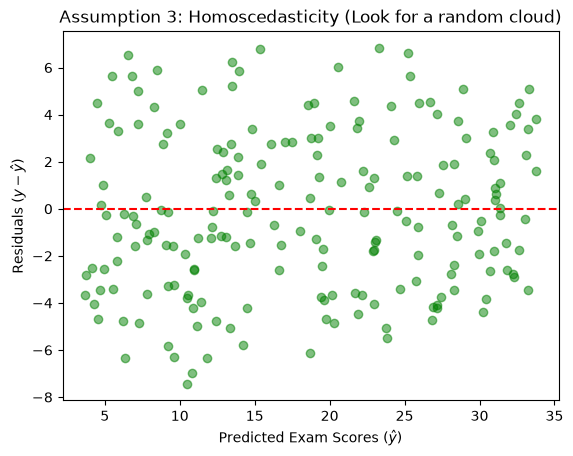

In [31]:
plt.scatter(df['y_pred'], df['residuals'], alpha=0.5, color="green")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Exam Scores ($\hat{y}$)")
plt.ylabel("Residuals ($y - \hat{y}$)")
plt.title("Assumption 3: Homoscedasticity (Look for a random cloud)")
plt.show()


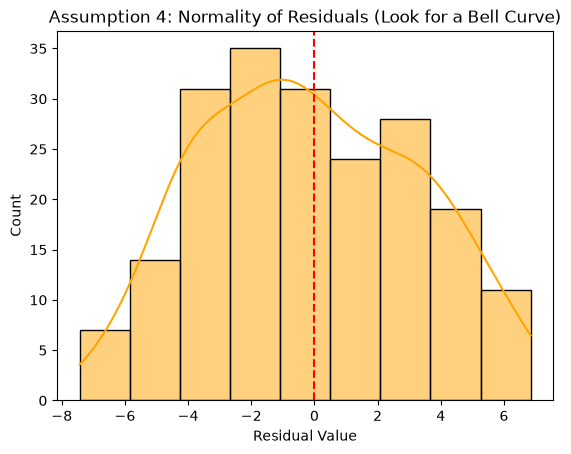

In [33]:
import seaborn as sns

sns.histplot(df['residuals'], kde=True, color="orange")
plt.axvline(0, color='red', linestyle='--')
plt.title("Assumption 4: Normality of Residuals (Look for a Bell Curve)")
plt.xlabel("Residual Value")
plt.show()


In [16]:
print("MSE Loss:", float(MSE(m, b, df)))


MSE Loss: 11.319127890849385


Now thats pretty damn good eh? Well, this is good and all, but linear regression actually has a closed form! 

# OLS Linear Regression

First let's us consider the Residual Sum of Squares (RSS) $$RSS = \sum_{i}(y_i - \hat{y_i})^{2}\\=\sum_{i}(y_i - mx_i + b)^{2}$$

Ok now, let's expand this out:
$$y = m_1x_1 + m_2x_2 + ... + b$$

If we let x0 = 1 and m0 = b we get:
$$X = \begin{pmatrix}
1 & x_1 & x_2 ...
\end{pmatrix}\\[1em]
\beta = \begin{pmatrix}
b & m_1 & m_2 ...
\end{pmatrix}$$

So using this, we can represent RSS as:

$$RSS = (y - X\beta)^{T}(y - X\beta)$$

So now we want to find the optimal beta that minimises RSS. To do this, lets first start by expanding RSS:

$$RSS = y^{T}y-\beta^{T}X^{T}y-y^{T}X\beta + \beta^{T}X^{T}X\beta\\[1em]=y^{T}y-2\beta^{T}X^{T}y+ \beta^{T}X^{T}X\beta$$

Now, we differentiate RSS with respect to beta:
$$\frac{\partial RSS}{\partial \beta} = 0 - 2X^{T}y + 2\beta^{T}X^{T}X=0\\[1em]=>X^{T}y = \beta^{T}X^{T}X$$

To find the optimal beta, we can shift things around to get the following:

$$\hat\beta = (X^{T}X)^{-1}X^{T}y$$

In [25]:
class LinearRegressionClosed:
    def __init__(self):
        self.coef_ = None
        self.inter_ = 0.0
    
    def fit(self, x, y):
        X = np.array(x)
        Y = np.array(y)

        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        A = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        self.coef_ = A[1]
        self.inter_ = A[0]

    def predict(self, X):
        X = np.array(X)

        return X @ self.coef_ + self.inter_


In [26]:
OLS_mod = LinearRegressionClosed()

OLS_mod.fit(df["Hours_Studied"], df["Exam_Score"])

print(OLS_mod.coef_, OLS_mod.inter_)


3.532122588972585 -0.7220660968802715


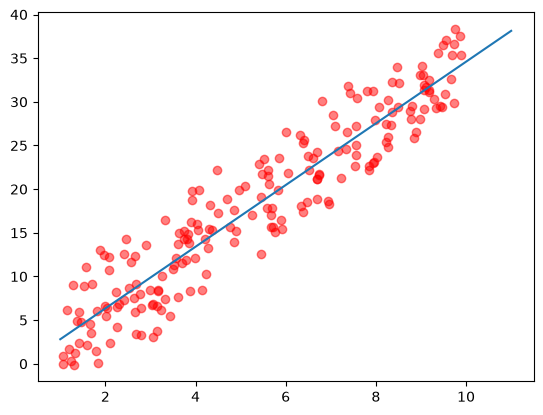

In [28]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"], alpha = 0.5, color = "red")
plt.plot(list(range(1, 12)), [x * OLS_mod.coef_ + OLS_mod.inter_ for x in range(1, 12)])
plt.show()


In [29]:
print("MSE Loss:", float(MSE(OLS_mod.coef_, OLS_mod.inter_, df)))


MSE Loss: 11.181991513369885


We can see that the OLS MSE will be lower as it is the mathematical ideal. 

# Assumptions

Linear Regression assumes the data fits a couple of categories. 

## 1. Linearity
The first is that the response variable has a linear relationship with the features (duh)

## 2. Independence
This means that the response now shouldn't depend on any response values before. This makes linear regression maybe not the best choice in applications such as time-series data. 

## 3. Homoscedascity
We basically want constant variance regardless of the value of the features and response. If variance increases with features or response, we have a heteroscedastic dataset. 

## 4. Normality of Residuals
We also assume that the residuals from the best-fit line to the datapoints are normally distributed. If breached, could mean that the data doesn't follow a linear regression, response is highly skewed, or there are severe outliers. 

Thanks to NeuralNine for the code and derivations. This is just for my own understanding and Latex practice. 